# Interactive Reduced-Order Geomodel for Rapid Screening of CO₂ Plume Migration

### Purpose:
This notebook provides a simple, interactive, physics-informed screening tool to visualize CO₂ plume movement over time and analyze key parameters related to geological carbon storage (GCS). It's designed for rapid assessment and understanding of fundamental GCS processes, rather than high-fidelity reservoir simulation.

## Assumptions and Limitations

This reduced-order model relies on several simplifying assumptions and has inherent limitations:

1.  **Simplified Physics:** The model uses simplified equations for Darcy flow, radial growth, and buoyancy-driven migration. These are approximations and do not capture the full complexity of multiphase flow in heterogeneous porous media.
2.  **Homogeneous Reservoir:** Assumes a homogeneous reservoir within the modeled area, neglecting small-scale variations in porosity, permeability, and thickness.
3.  **Constant Properties:** Fluid and rock properties (e.g., densities, viscosities, porosity, permeability) are assumed constant over time and space, which may not hold true under dynamic reservoir conditions.
4.  **Instantaneous Equilibrium:** Dissolution and residual trapping are modeled with simplified fractions or coefficients, implying near-instantaneous processes rather than kinetically limited ones.
5.  **2D Representation:** Plume migration is visualized in 2D, with vertical effects (like gravity override) simplified into an updip migration component. The model doesn't fully resolve complex 3D plume dynamics.
6.  **No Coupled Geomechanics/Geochemistry:** The model does not include coupled geomechanical effects (e.g., rock deformation due to pressure buildup) or complex geochemical reactions beyond simple dissolution.
7.  **Screening Tool Only:** This is explicitly a screening tool and not a replacement for detailed, high-fidelity reservoir simulators (e.g., ECLIPSE, TOUGH2, CMG, Petrel) which account for more complex physics, heterogeneity, and numerical precision.
8.  **Mass Balance Approximations:** While a mass balance check is included, certain simplifications in the trapping mechanisms might lead to minor discrepancies. Leakage is a simplified flag and not a detailed flow calculation.
9.  **Caprock and Faults:** Caprock integrity and fault leakage are represented by simplified pressure thresholds and distance checks, without detailed fault seal analysis.

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Optional imports if plotly is needed later
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Define Constants and Helper Functions

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Optional imports if plotly is needed later
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots

# Physical Constants
g = 9.81  # m/s^2, acceleration due to gravity

# Unit Conversion Factors
md_to_m2 = 9.869233e-16 # millidarcy to m^2
pa_s_to_cp = 1000 # Pa.s to centipoise
Mt_to_kg = 1e9 # 1 megatonne (Mt) = 1e9 kg
year_to_seconds = 365.25 * 24 * 3600 # years to seconds

print("Constants and unit conversion factors defined.")

# --- Geomodel Parameters and Generation ---
def generate_geomodel(nx=100, ny=100, x_max=10000, y_max=10000, injection_x=0, injection_y=0,
                      base_porosity=0.2, porosity_variation=0.05,
                      base_permeability_md=500, perm_variation_factor=0.5,
                      shale_barrier_location=None, shale_barrier_width=500,
                      fault_location=None, fault_width=100, dip_angle_deg=5):

    x = np.linspace(-x_max/2, x_max/2, nx)
    y = np.linspace(-y_max/2, y_max/2, ny)
    X, Y = np.meshgrid(x, y)

    # Porosity field (uniform with some random noise)
    porosity_field = np.full((ny, nx), base_porosity) + np.random.rand(ny, nx) * porosity_variation - porosity_variation/2
    porosity_field = np.clip(porosity_field, 0.05, 0.4)

    # Permeability field (layered or spatially variable)
    permeability_field_md = np.full((ny, nx), base_permeability_md) * (
        1 + perm_variation_factor * (np.sin(X/x_max * np.pi * 2) + np.cos(Y/y_max * np.pi * 3)) / 2
    )
    permeability_field_md = np.clip(permeability_field_md, 10, 2000)

    # Shale barriers (low permeability zones)
    if shale_barrier_location is not None:
        # Example: a vertical barrier
        barrier_start_idx = np.searchsorted(x, shale_barrier_location - shale_barrier_width/2)
        barrier_end_idx = np.searchsorted(x, shale_barrier_location + shale_barrier_width/2)
        if barrier_start_idx < nx and barrier_end_idx > 0:
            permeability_field_md[:, barrier_start_idx:barrier_end_idx] = 1 # very low perm

    # Fault/Spill-point boundary (represented as a low perm zone for visualization)
    if fault_location is not None:
        fault_start_idx = np.searchsorted(x, fault_location - fault_width/2)
        fault_end_idx = np.searchsorted(x, fault_location + fault_width/2)
        if fault_start_idx < nx and fault_end_idx > 0:
            permeability_field_md[:, fault_start_idx:fault_end_idx] = 0.1 # effectively impermeable

    # Dip is handled in the plume dynamics function, but can be visualized as a gradient
    dip_gradient = np.tan(np.deg2rad(dip_angle_deg)) # for conceptual visualization if needed

    geomodel = {
        'x_coords': x,
        'y_coords': y,
        'porosity_field': porosity_field,
        'permeability_field_md': permeability_field_md,
        'nx': nx,
        'ny': ny,
        'x_max': x_max,
        'y_max': y_max,
        'injection_point': (injection_x, injection_y),
        'dip_angle_deg': dip_angle_deg,
        'fault_location': fault_location # This is the x-coordinate of the fault line
    }
    return geomodel

# Generate a default geomodel for initial setup
default_geomodel_params = {
    'nx': 200, 'ny': 100, # Increased resolution for better visuals
    'x_max': 10000, 'y_max': 5000, # Total domain size
    'injection_x': 0, 'injection_y': 0, # Center injection
    'base_porosity': 0.2, 'porosity_variation': 0.02,
    'base_permeability_md': 200, 'perm_variation_factor': 0.3,
    'shale_barrier_location': None, # No barrier by default
    'fault_location': 5000, # Fault at 5km in +x direction
    'dip_angle_deg': 5
}
geomodel_data = generate_geomodel(**default_geomodel_params)

print("Geomodel generation function defined and default geomodel created.")

Constants and unit conversion factors defined.
Geomodel generation function defined and default geomodel created.


## 3. Define Reduced-Order Plume Model

In [11]:
def calculate_plume_dynamics(Q_Mt_year, inj_duration_years, phi, k_md, h, dip_angle_deg,
                             kx_ky_ratio, rho_CO2, rho_brine, mu_CO2_Pa_s,
                             time_steps):

    # Convert inputs to consistent units
    Q_kg_s = Q_Mt_year * Mt_to_kg / year_to_seconds # kg/s
    k_m2 = k_md * md_to_m2 # m^2
    mu_CO2 = mu_CO2_Pa_s # Pa.s
    dip_angle_rad = np.deg2rad(dip_angle_deg)

    # Initialize lists to store results over time
    times = []
    mobile_mass_list = []
    total_injected_mass_list = []
    plume_a_list = [] # Major axis of ellipse
    plume_b_list = [] # Minor axis of ellipse
    updip_shift_list = [] # Center shift due to buoyancy
    pressure_front_radius_list = []

    # Initial conditions
    cumulative_injected_mass = 0.0
    mobile_mass = 0.0

    # Parameters for pressure front radius (simplified)
    alpha = 3.0 # Factor for pressure front radius relative to CO2 plume radius

    for t_idx, current_time_years in enumerate(time_steps):
        times.append(current_time_years)
        dt = time_steps[t_idx] - (time_steps[t_idx-1] if t_idx > 0 else 0)
        current_time_seconds = current_time_years * year_to_seconds

        # 1. Injected Mass Calculation
        mass_injected_this_step = 0.0
        if current_time_years <= inj_duration_years:
            mass_injected_this_step = Q_kg_s * dt * year_to_seconds
        cumulative_injected_mass += mass_injected_this_step

        # All injected mass is considered mobile for visualization in this simplified version
        mobile_mass = cumulative_injected_mass

        # Recalculate mobile CO2 volume based on adjusted mobile_mass
        mobile_co2_volume = mobile_mass / rho_CO2 if rho_CO2 > 0 else 0
        mobile_pore_volume = mobile_co2_volume / phi if phi > 0 else 0

        if mobile_pore_volume > 0:
            r_eff = np.sqrt(mobile_pore_volume / (np.pi * h))
        else:
            r_eff = 0.0

        # 3. Buoyancy-driven updip migration
        delta_rho = rho_brine - rho_CO2
        buoyancy_factor = delta_rho * g * k_m2 / mu_CO2 if mu_CO2 > 0 else 0 # Avoid division by zero
        Cb = 0.005 # Scaling constant for updip shift (m/s equivalent factor)
        updip_shift = Cb * buoyancy_factor * np.sin(dip_angle_rad) * current_time_seconds

        # Ellipse axes based on effective radius and anisotropy
        a_base = r_eff * np.sqrt(kx_ky_ratio)
        b_base = r_eff / np.sqrt(kx_ky_ratio) if kx_ky_ratio > 0 else r_eff # Avoid division by zero

        # Final plume dimensions (incorporating updip shift)
        plume_a = a_base + np.abs(updip_shift) # Major axis (elongated in updip direction)
        plume_b = b_base # Minor axis

        # 9. Pressure front radius larger than CO₂ plume radius
        # Using r_base for pressure front as it's less affected by trapping (which is now removed)
        r_base = np.sqrt(cumulative_injected_mass / rho_CO2 / phi / (np.pi * h)) if (rho_CO2 > 0 and phi > 0 and h > 0) else 0.0
        pressure_front_radius = alpha * r_base

        # Store results
        mobile_mass_list.append(mobile_mass)
        total_injected_mass_list.append(cumulative_injected_mass)
        plume_a_list.append(plume_a)
        plume_b_list.append(plume_b)
        updip_shift_list.append(updip_shift)
        pressure_front_radius_list.append(pressure_front_radius)

    results_df = pd.DataFrame({
        'Time_Years': times,
        'Injected_Mass_kg': total_injected_mass_list,
        'Mobile_Mass_kg': mobile_mass_list,
        'Plume_Major_Axis_m': plume_a_list,
        'Plume_Minor_Axis_m': plume_b_list,
        'Updip_Shift_m': updip_shift_list,
        'Pressure_Front_Radius_m': pressure_front_radius_list
    })

    return results_df

print("Reduced-order plume model function defined.")

Reduced-order plume model function defined.


## 4. Build Interactive Widgets

In [4]:
time_steps = np.arange(0, 101, 1).tolist() # 0 to 100 years, step 1 year

# Define default parameters for the widgets
default_params = {
    'Q_Mt_year': 1.0, # Mt/year
    'inj_duration_years': 30.0,
    'phi': 0.2,
    'k_md': 500.0, # mD
    'h': 50.0, # m
    'dip_angle_deg': 5.0, # degrees
    'kx_ky_ratio': 1.0, # dimensionless
    'rho_CO2': 700.0, # kg/m^3
    'rho_brine': 1050.0, # kg/m^3
    'mu_CO2_Pa_s': 3.0e-5, # Pa.s (approx 0.03 cP)

    # New Geomodel Parameters
    'geomodel_base_porosity': 0.2,
    'geomodel_porosity_variation': 0.02,
    'geomodel_base_permeability_md': 200,
    'geomodel_perm_variation_factor': 0.3,
    'geomodel_shale_barrier_enabled': False,
    'geomodel_shale_barrier_location': 0.0,
    'geomodel_shale_barrier_width': 500.0,
    'fault_location_geomodel': 5000.0 # Renamed for clarity in context of geomodel, will be used directly
}

# Create interactive widgets
Q_widget = widgets.FloatSlider(
    value=default_params['Q_Mt_year'],
    min=0.1, max=10.0, step=0.1,
    description='Injection Rate (Mt/year):',
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
    layout=widgets.Layout(width='auto')
)

inj_duration_widget = widgets.IntSlider(
    value=default_params['inj_duration_years'],
    min=5, max=100, step=1,
    description='Injection Duration (years):',
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='auto')
)

phi_widget = widgets.FloatSlider(
    value=default_params['phi'],
    min=0.05, max=0.4, step=0.01,
    description='Porosity (phi):',
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
    layout=widgets.Layout(width='auto')
)

k_md_widget = widgets.FloatSlider(
    value=default_params['k_md'],
    min=10, max=2000, step=10,
    description='Permeability (mD):',
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='auto')
)

h_widget = widgets.FloatSlider(
    value=default_params['h'],
    min=10, max=200, step=5,
    description='Thickness (m):',
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='auto')
)

dip_angle_widget = widgets.FloatSlider(
    value=default_params['dip_angle_deg'],
    min=0.0, max=30.0, step=0.5,
    description='Dip Angle (degrees):',
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
    layout=widgets.Layout(width='auto')
)

kx_ky_ratio_widget = widgets.FloatSlider(
    value=default_params['kx_ky_ratio'],
    min=0.1, max=10.0, step=0.1,
    description='Anisotropy (kx/ky):',
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
    layout=widgets.Layout(width='auto')
)

rho_CO2_widget = widgets.FloatSlider(
    value=default_params['rho_CO2'],
    min=400, max=900, step=10,
    description='CO2 Density (kg/m^3):',
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='auto')
)

rho_brine_widget = widgets.FloatSlider(
    value=default_params['rho_brine'],
    min=1000, max=1200, step=10,
    description='Brine Density (kg/m^3):',
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='auto')
)

mu_CO2_widget = widgets.FloatSlider(
    value=default_params['mu_CO2_Pa_s'],
    min=1e-5, max=1e-4, step=1e-6,
    description='CO2 Viscosity (Pa.s):',
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='.1e',
    layout=widgets.Layout(width='auto')
)

# New Geomodel Widgets
geomodel_base_porosity_widget = widgets.FloatSlider(
    value=default_params['geomodel_base_porosity'],
    min=0.05, max=0.4, step=0.01,
    description='Geo Base Porosity:',
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
    layout=widgets.Layout(width='auto')
)

geomodel_porosity_variation_widget = widgets.FloatSlider(
    value=default_params['geomodel_porosity_variation'],
    min=0.0, max=0.1, step=0.01,
    description='Geo Porosity Variation:',
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
    layout=widgets.Layout(width='auto')
)

geomodel_base_permeability_md_widget = widgets.FloatSlider(
    value=default_params['geomodel_base_permeability_md'],
    min=10, max=2000, step=10,
    description='Geo Base Perm (mD):',
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='auto')
)

geomodel_perm_variation_factor_widget = widgets.FloatSlider(
    value=default_params['geomodel_perm_variation_factor'],
    min=0.0, max=1.0, step=0.1,
    description='Geo Perm Variation Factor:',
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
    layout=widgets.Layout(width='auto')
)

shale_barrier_enable_widget = widgets.Checkbox(
    value=default_params['geomodel_shale_barrier_enabled'],
    description='Enable Shale Barrier',
    indent=False,
    layout=widgets.Layout(width='auto')
)

shale_barrier_location_widget = widgets.FloatSlider(
    value=default_params['geomodel_shale_barrier_location'],
    min=-4000, max=4000, step=100,
    description='Shale Barrier Location (m):',
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    disabled=not default_params['geomodel_shale_barrier_enabled'], # Disable initially if not enabled
    layout=widgets.Layout(width='auto')
)

shale_barrier_width_widget = widgets.FloatSlider(
    value=default_params['geomodel_shale_barrier_width'],
    min=10, max=1000, step=10,
    description='Shale Barrier Width (m):',
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    disabled=not default_params['geomodel_shale_barrier_enabled'], # Disable initially if not enabled
    layout=widgets.Layout(width='auto')
)

fault_location_geomodel_widget = widgets.FloatSlider(
    value=default_params['fault_location_geomodel'],
    min=100, max=20000, step=100,
    description='Fault/Spill-point Location (m):',
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='auto')
)

def on_shale_barrier_enable_change(change):
    shale_barrier_location_widget.disabled = not change.new
    shale_barrier_width_widget.disabled = not change.new

shale_barrier_enable_widget.observe(on_shale_barrier_enable_change, names='value')

# Group widgets for display (optional, but makes layout cleaner)
param_widgets = [
    Q_widget, inj_duration_widget, phi_widget, k_md_widget, h_widget,
    dip_angle_widget, kx_ky_ratio_widget, rho_CO2_widget, rho_brine_widget,
    mu_CO2_widget,
    widgets.HTML(value="<hr><b>Geomodel Parameters:</b>"), # Separator
    geomodel_base_porosity_widget,
    geomodel_porosity_variation_widget,
    geomodel_base_permeability_md_widget,
    geomodel_perm_variation_factor_widget,
    shale_barrier_enable_widget,
    shale_barrier_location_widget,
    shale_barrier_width_widget,
    fault_location_geomodel_widget
]

print("Interactive widgets defined.")

Interactive widgets defined.


## 5. Create Four-Tab Interface

### Tab 1: Plume Migration Visualization

Tab 1 (Plume Migration Visualization) created and displayed.


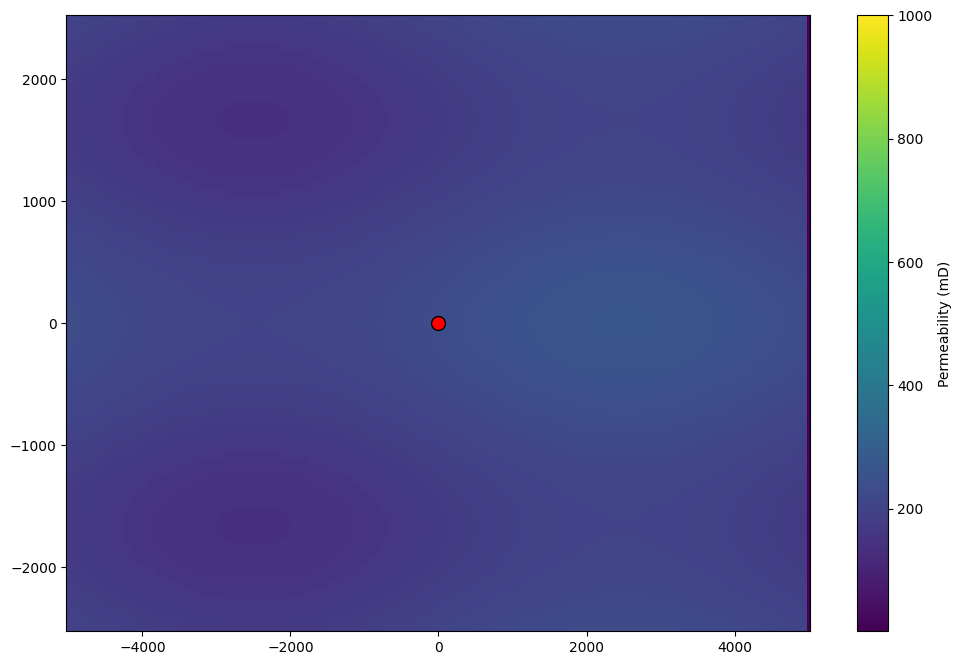

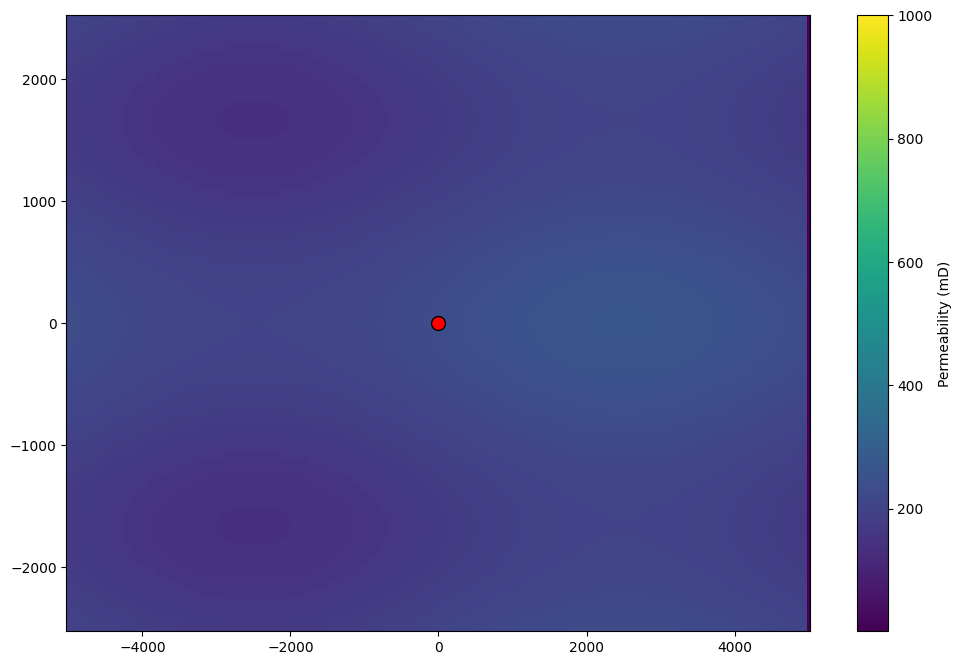

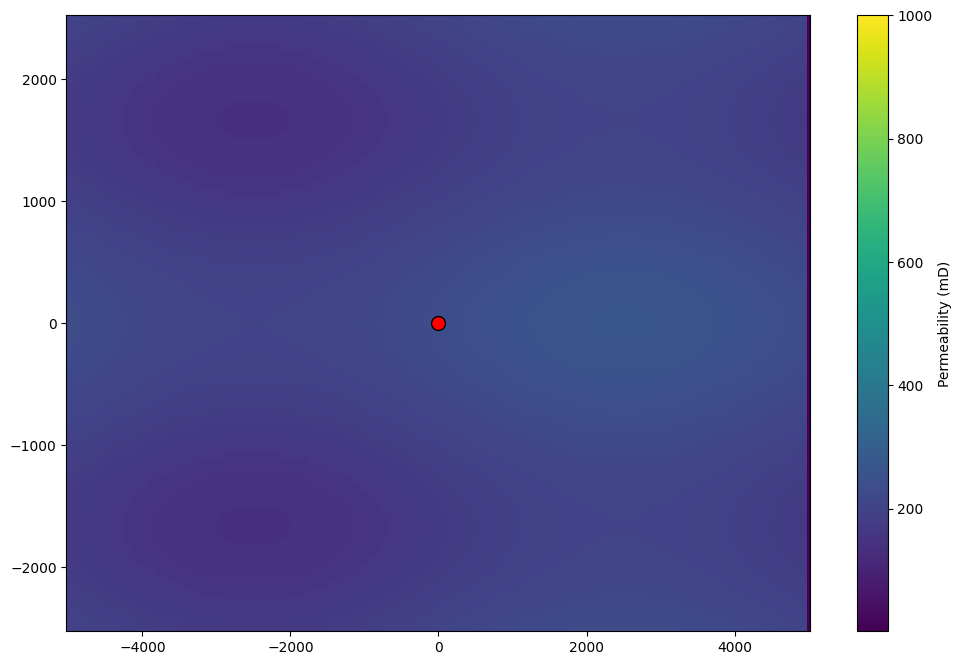

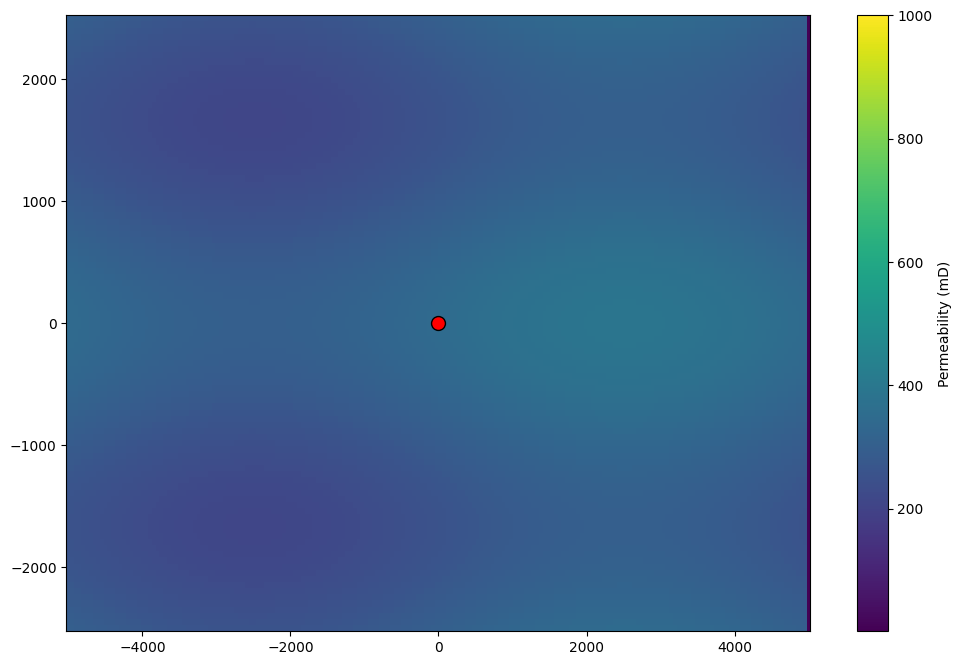

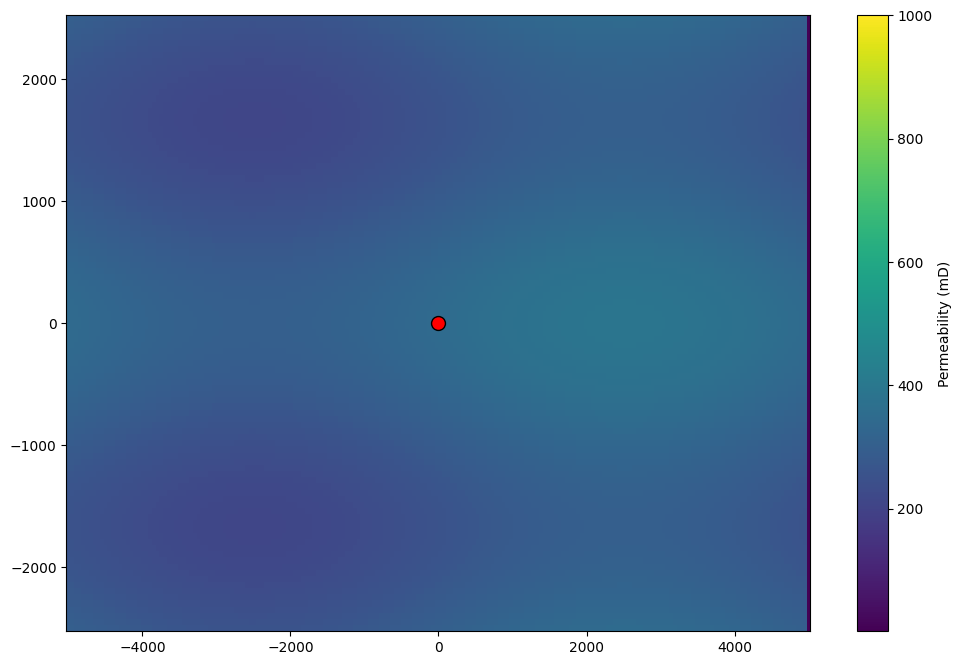

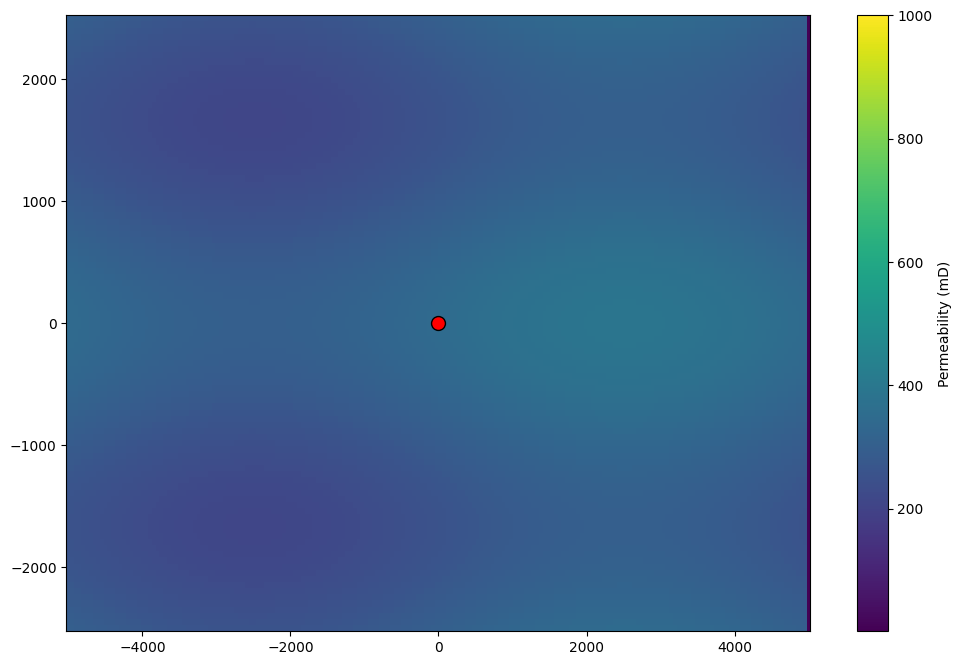

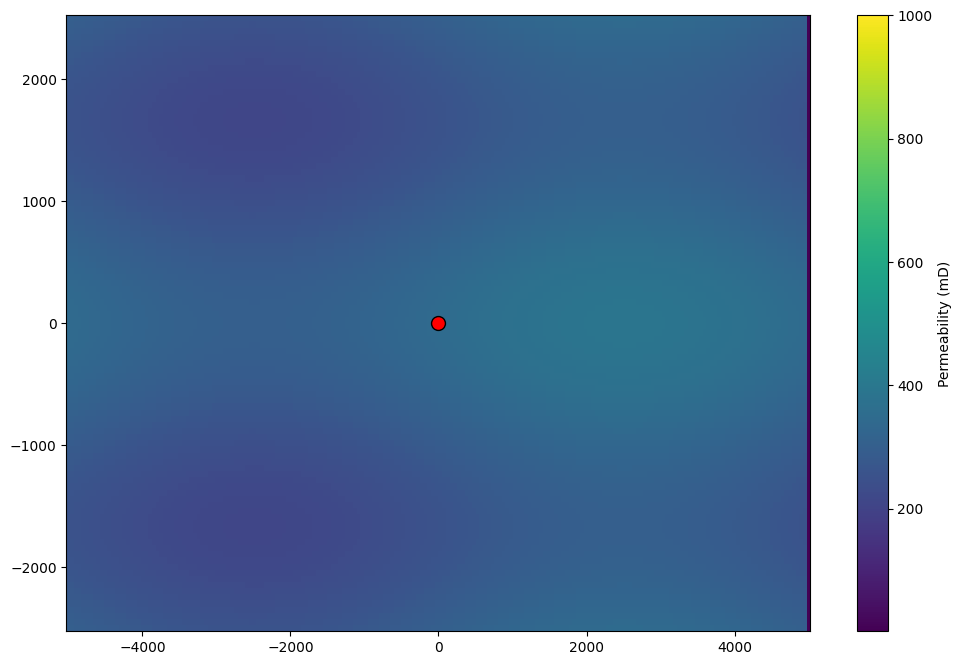

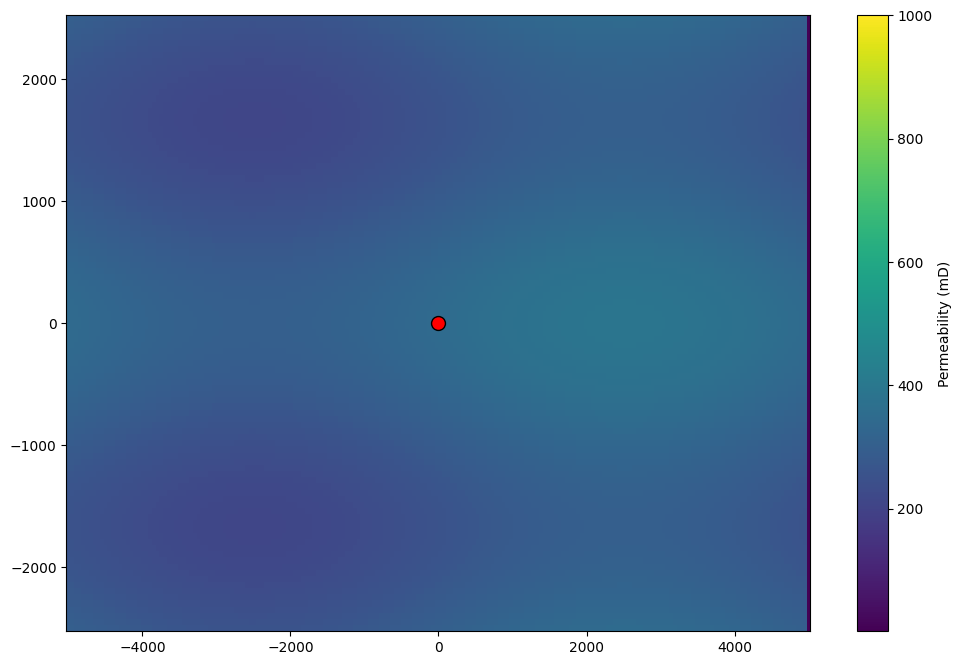

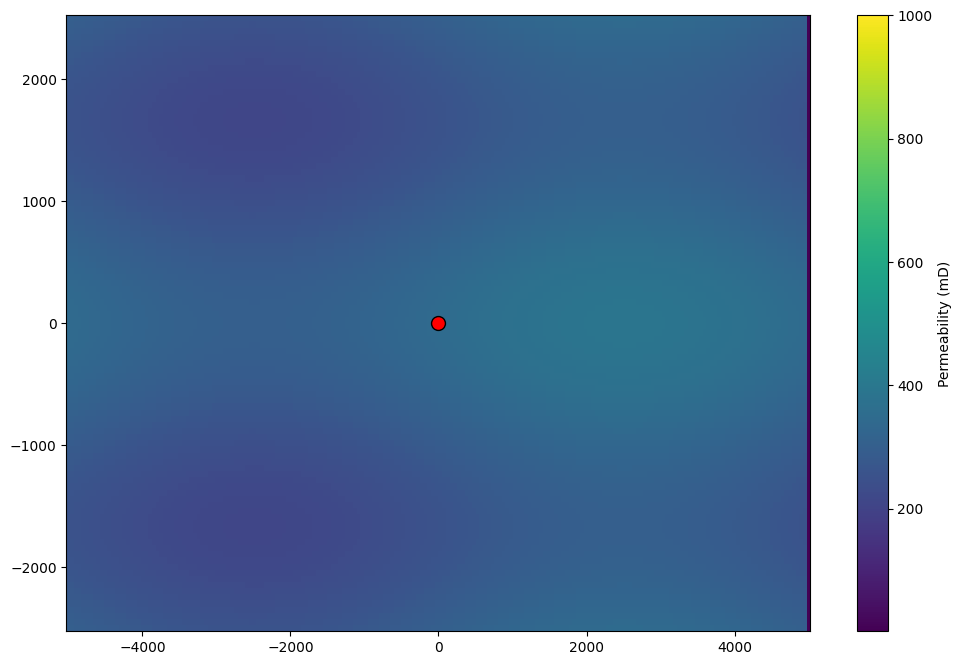

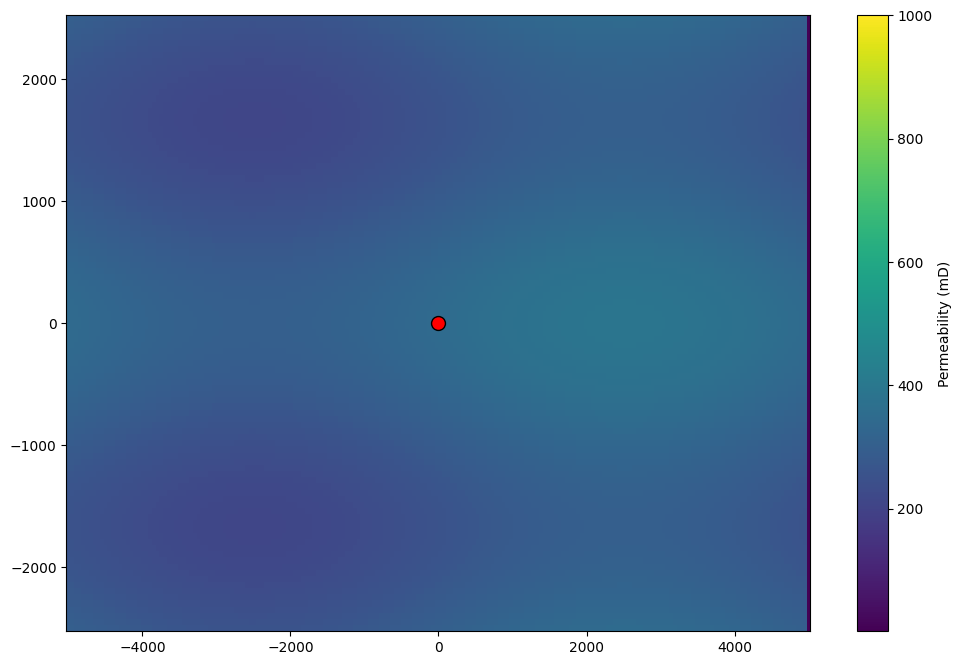

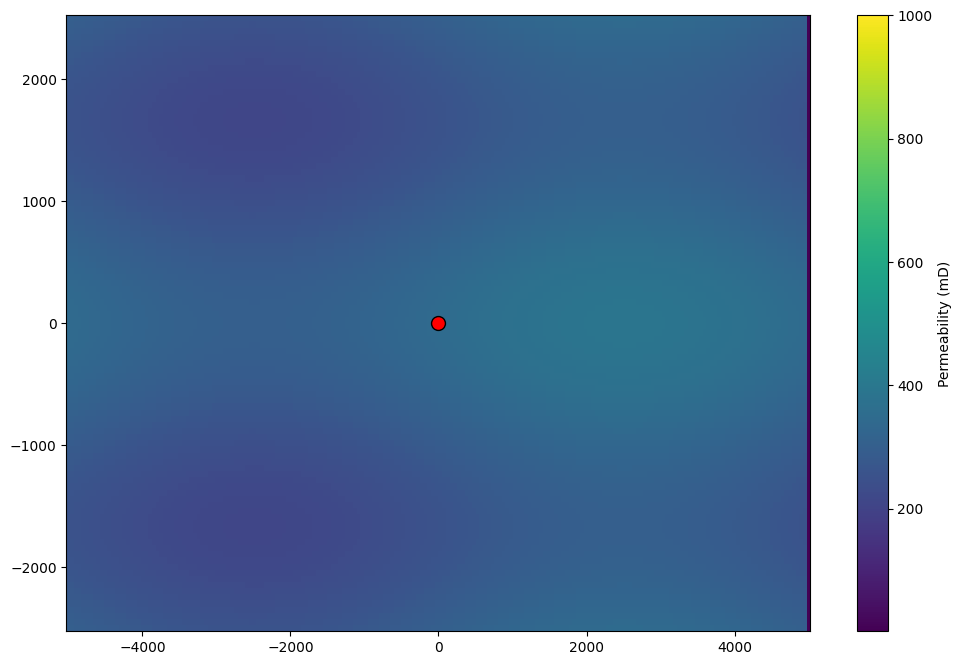

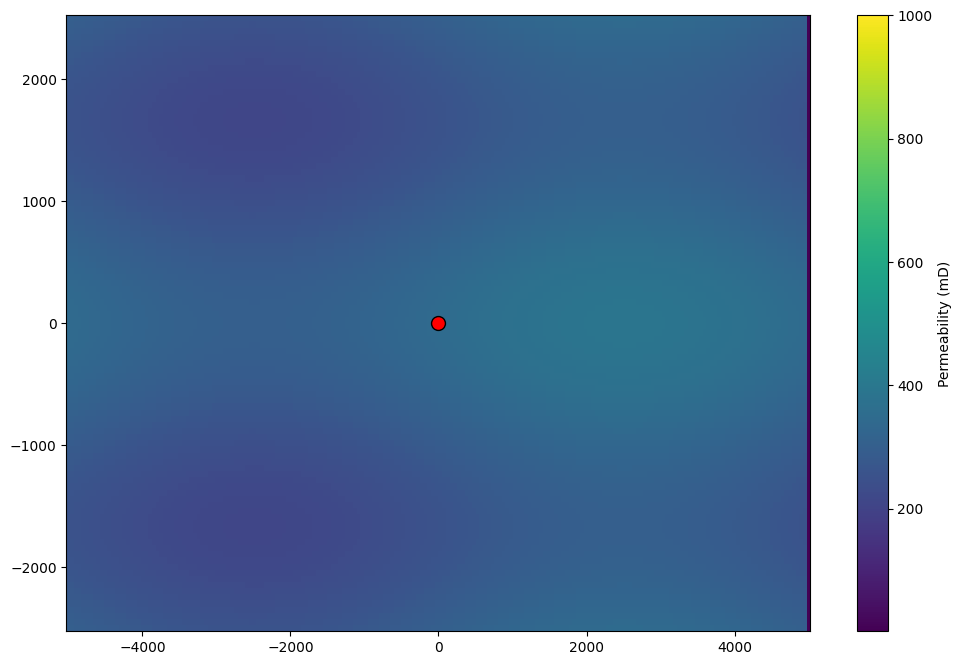

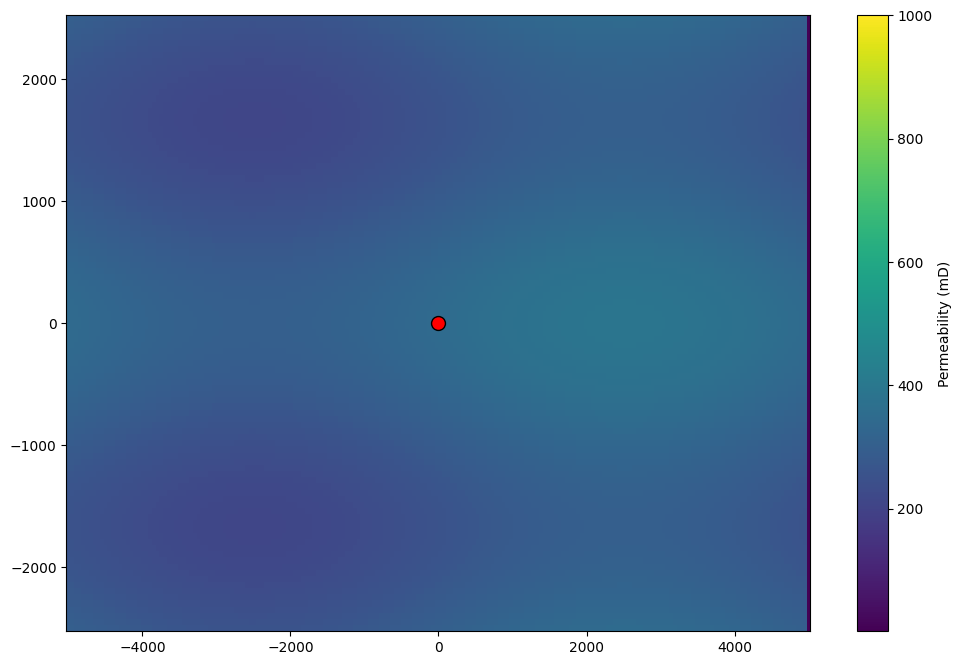

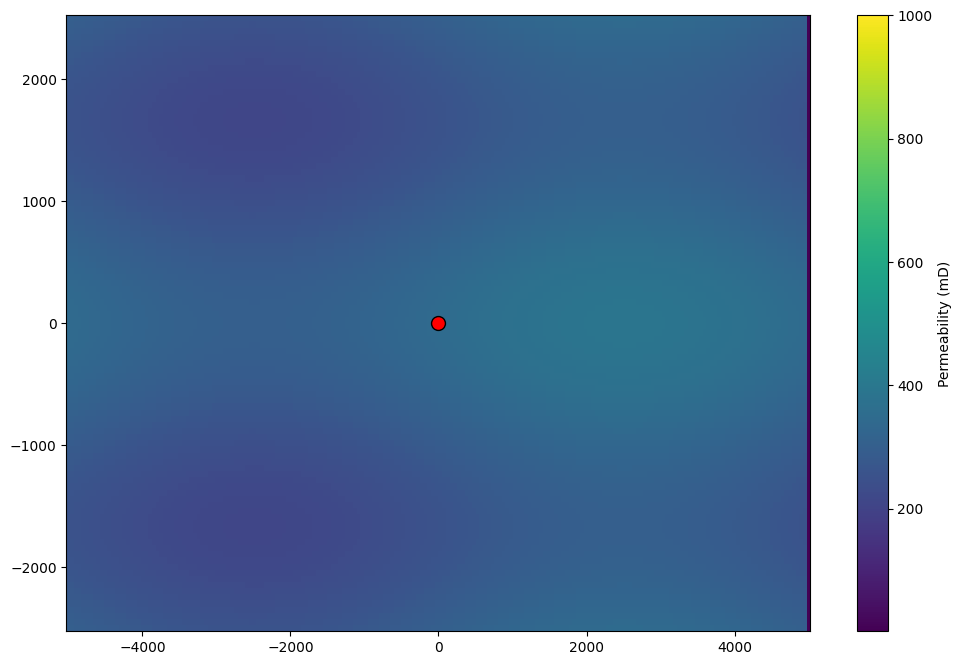

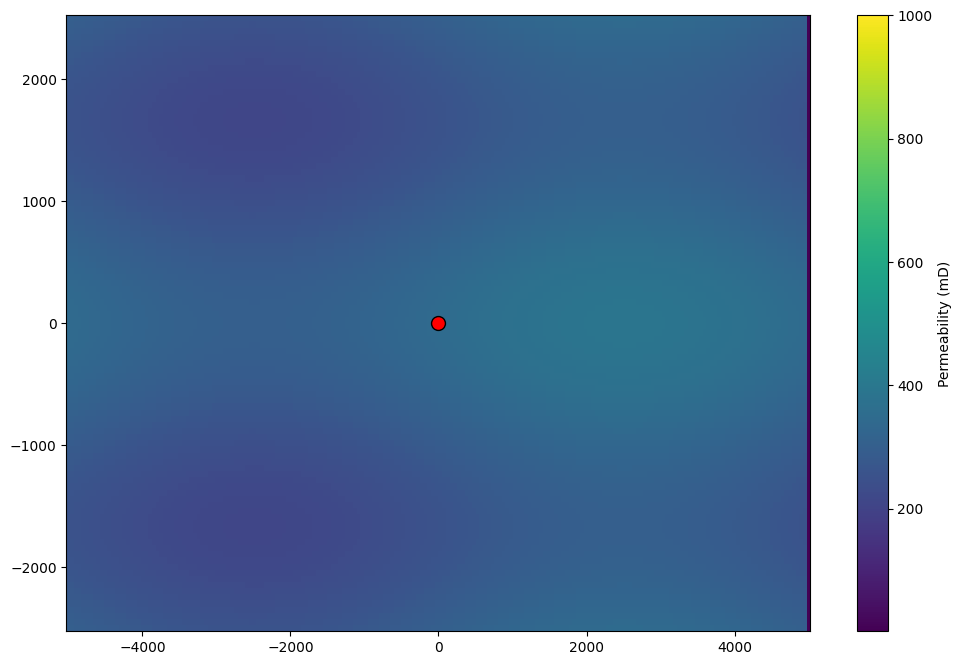

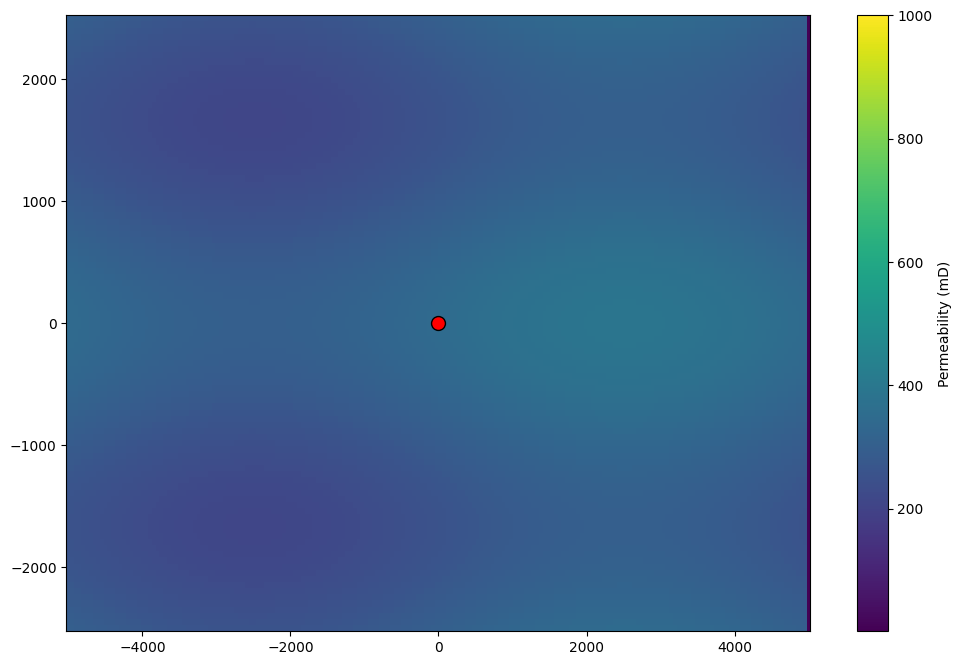

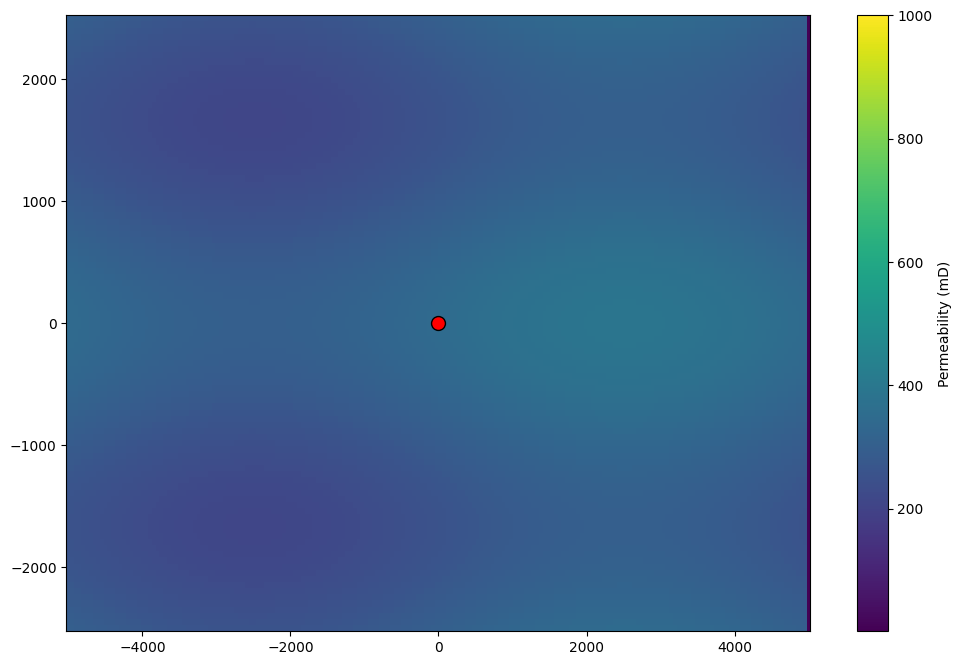

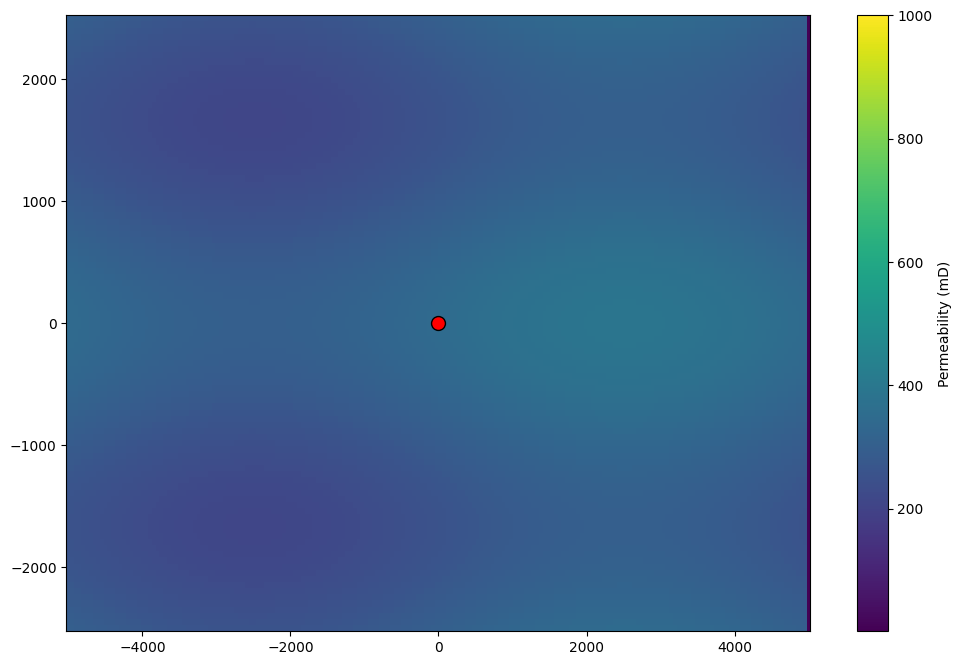

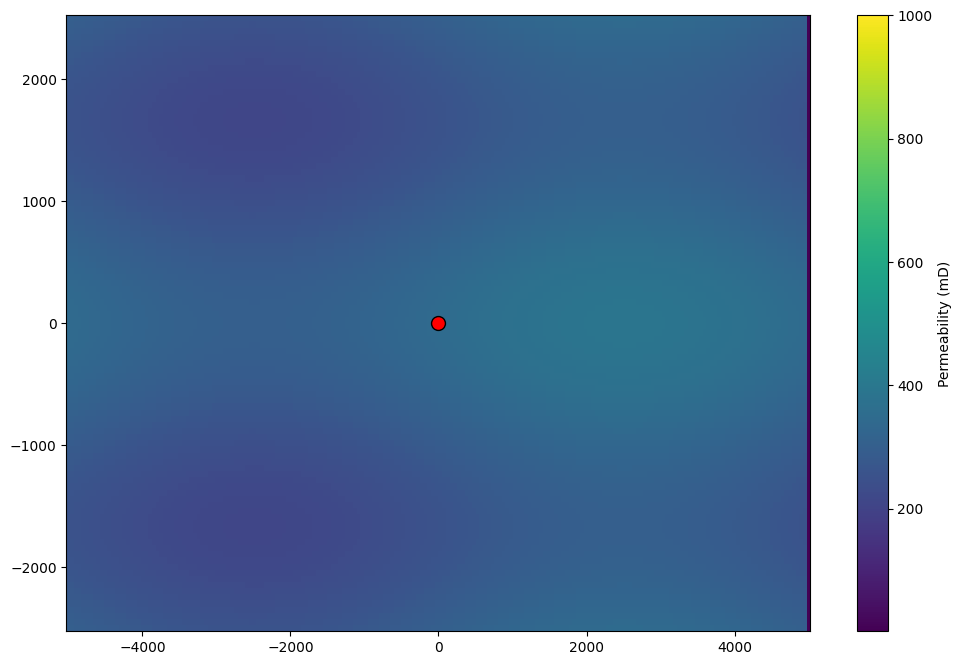

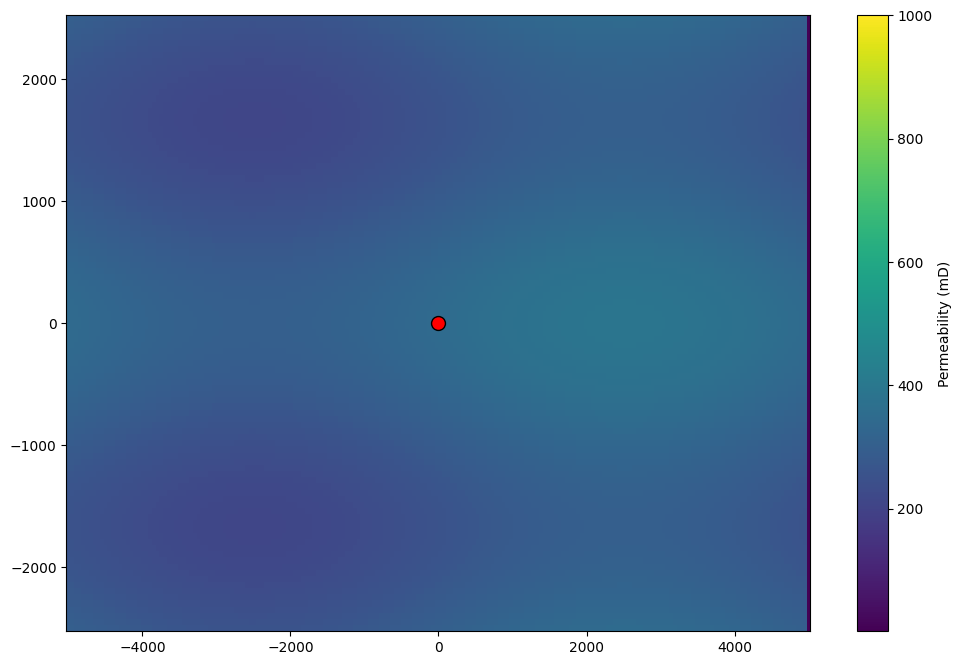

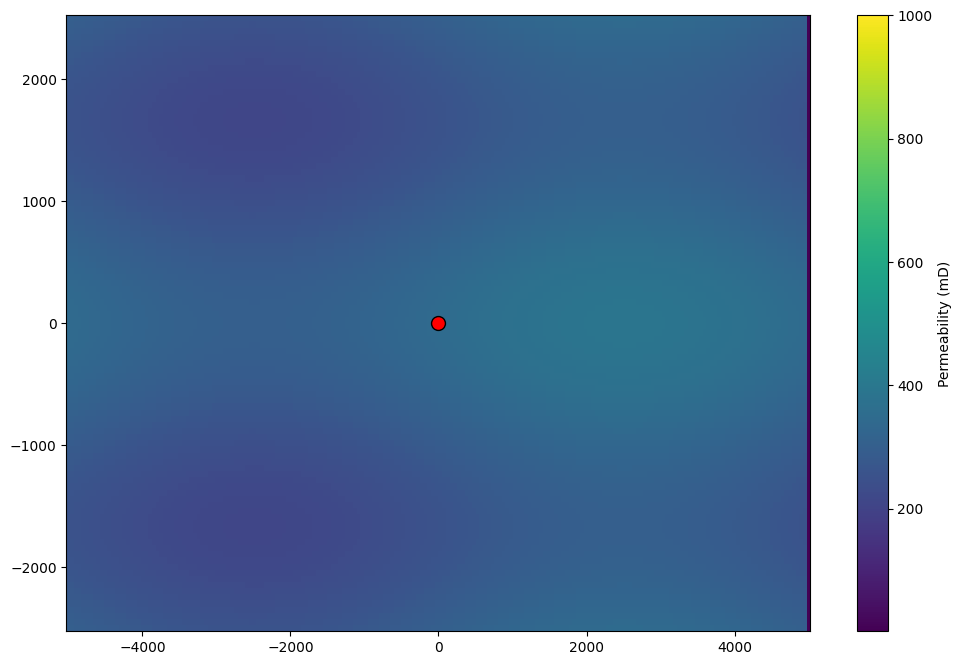

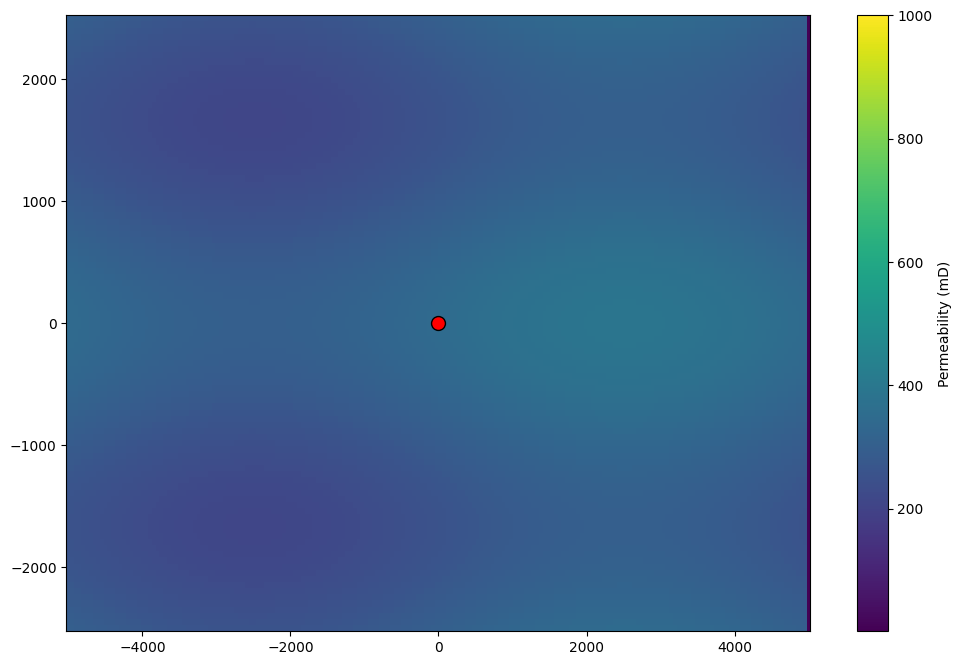

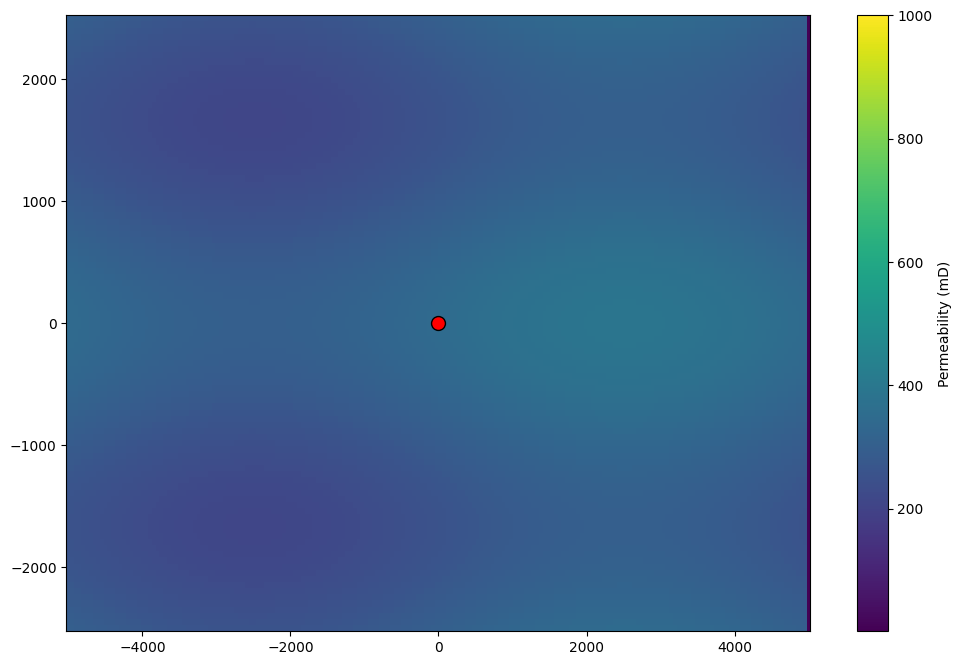

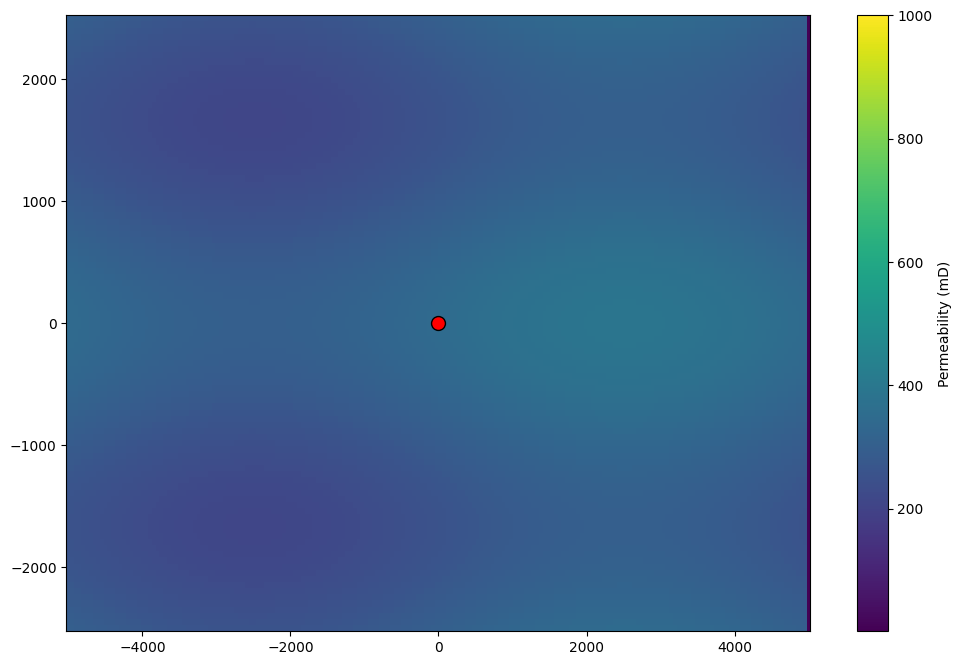

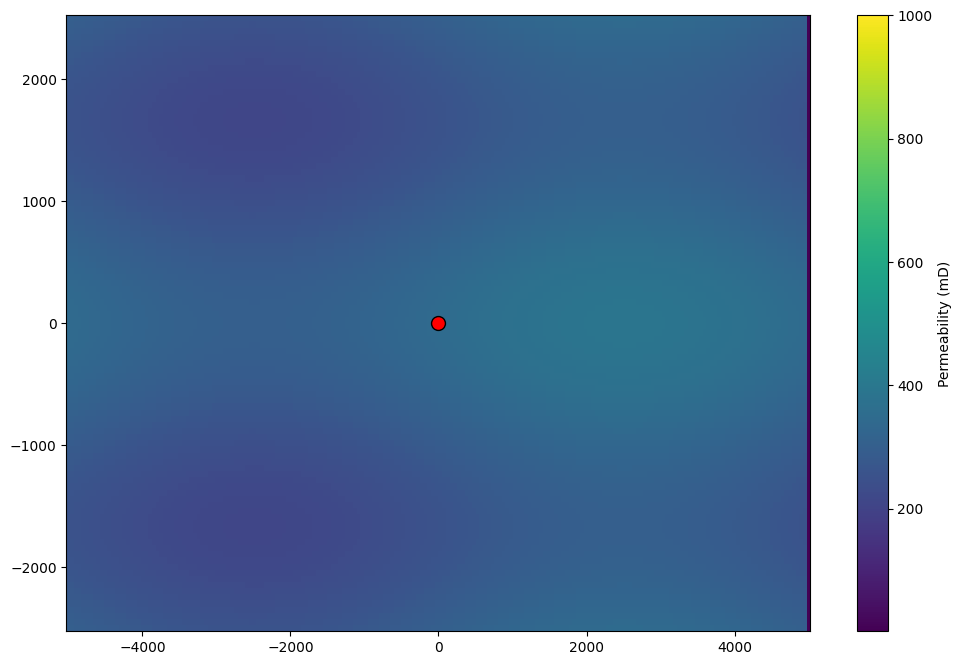

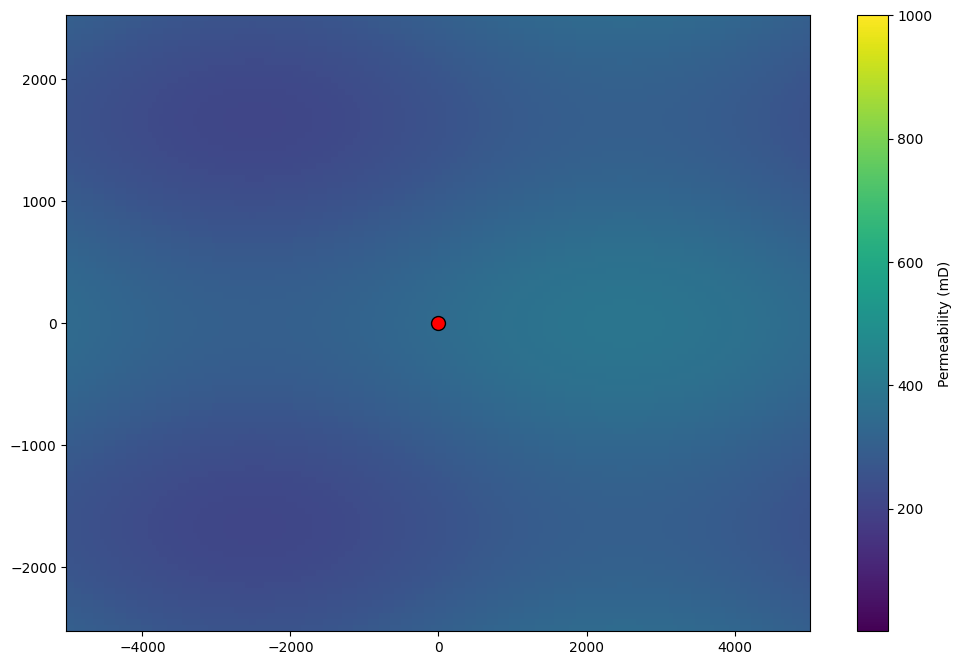

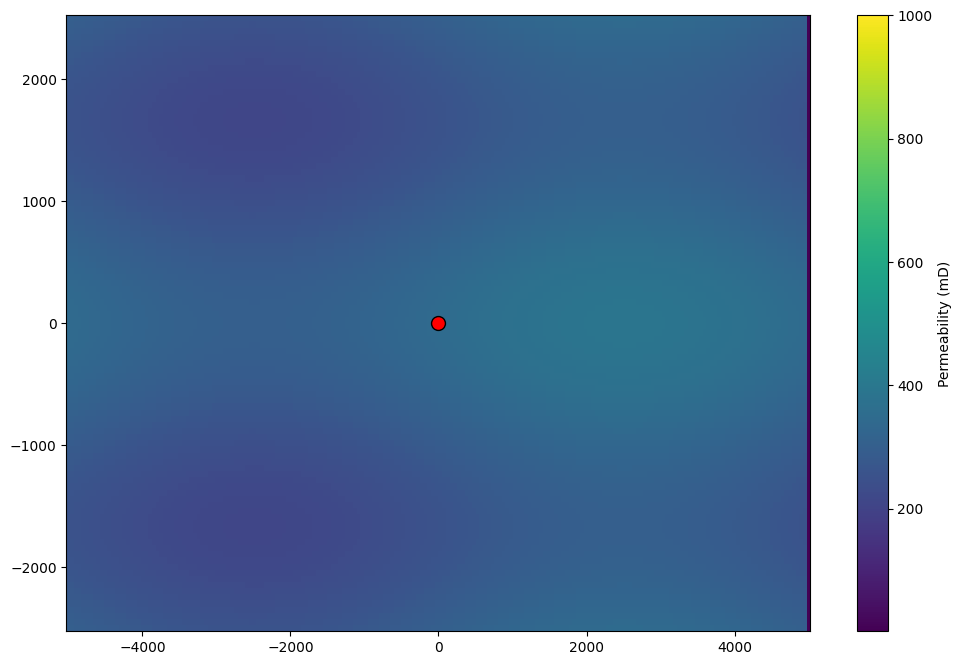

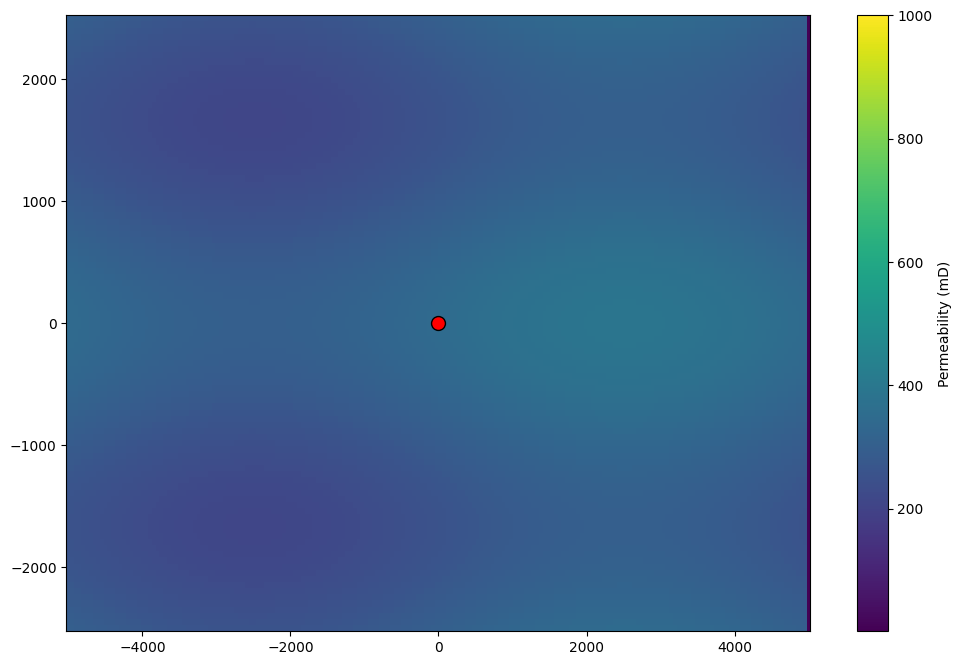

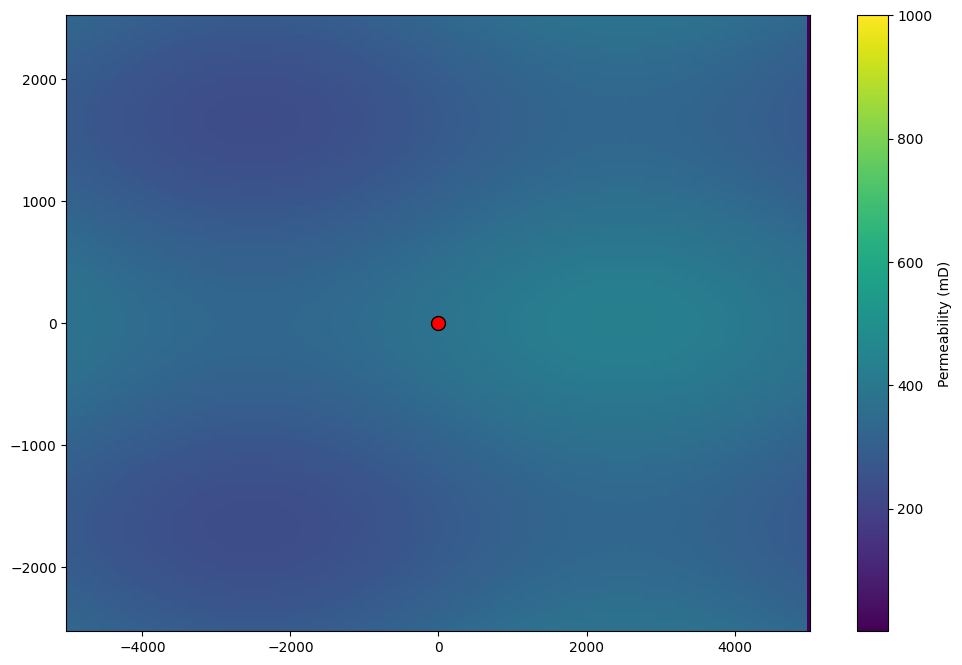

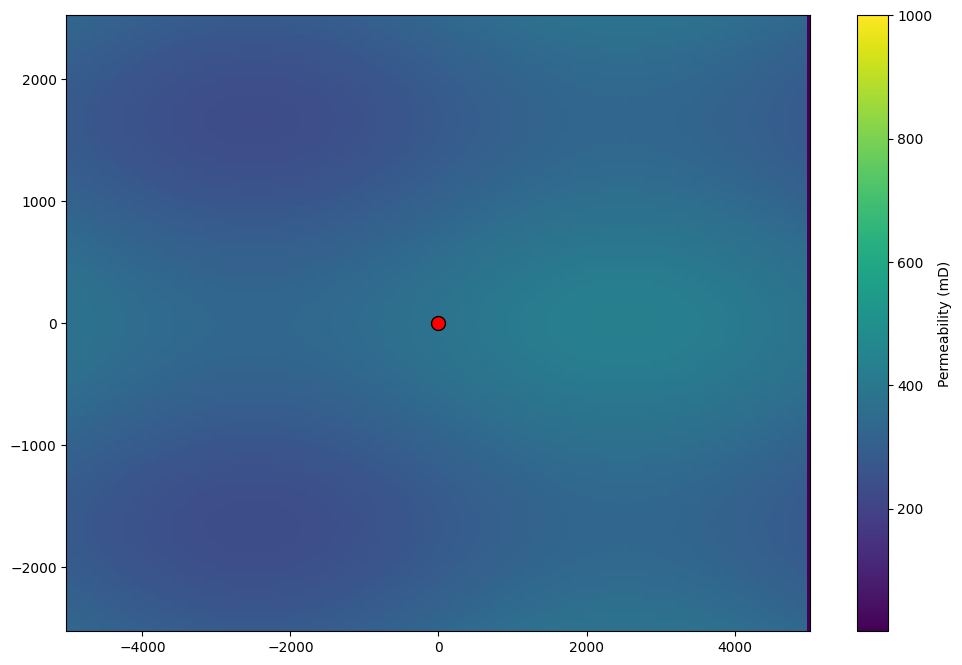

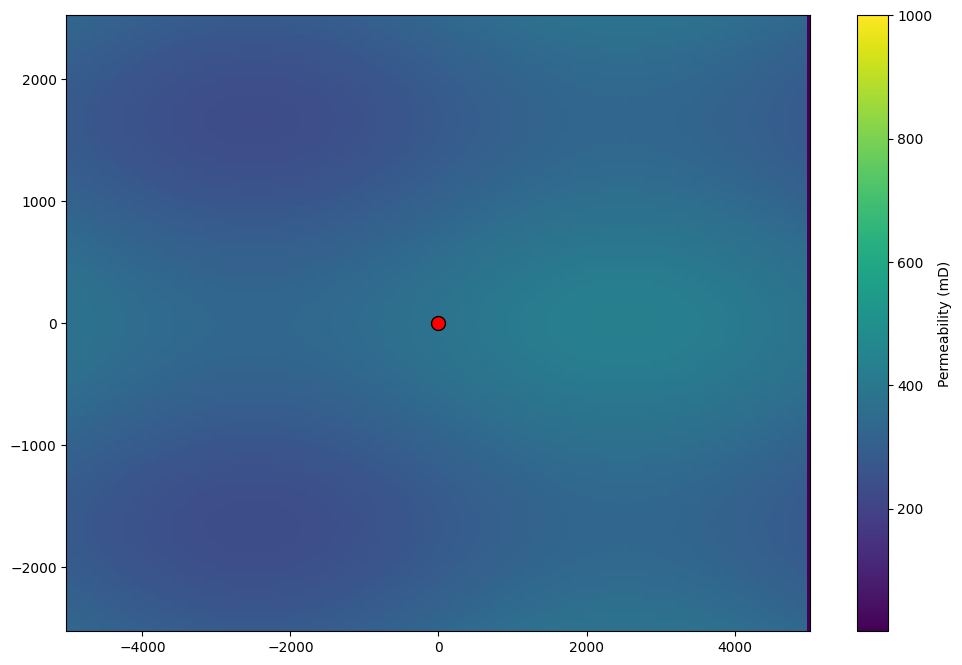

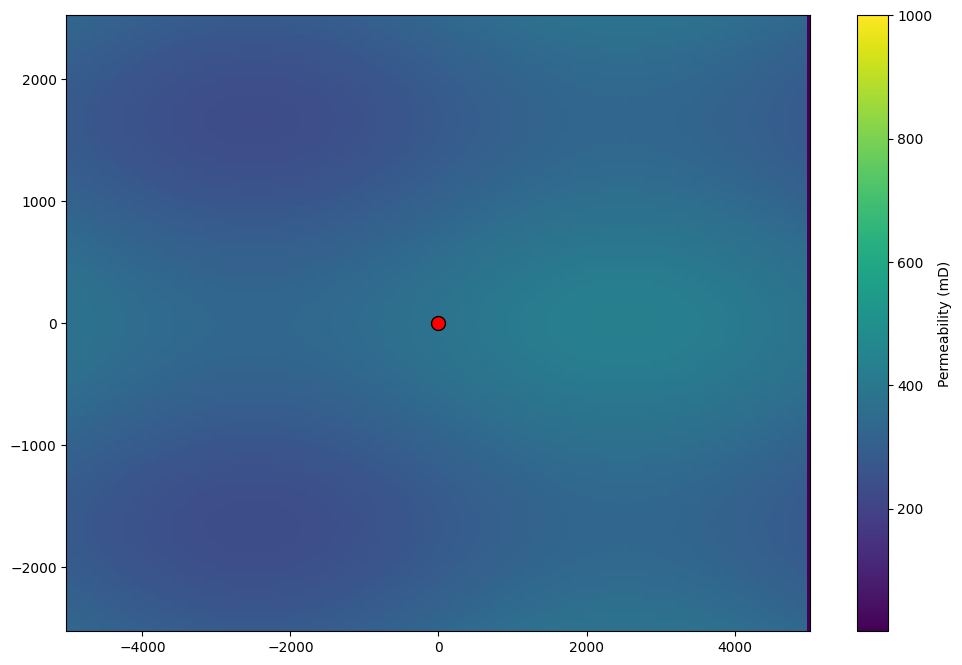

In [5]:
time_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(time_steps) - 1,
    step=1,
    description='Time (Years):',
    continuous_update=True, # Changed to True to ensure immediate updates
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='auto')
)

play_button = widgets.Play(
    value=0,
    min=0,
    max=len(time_steps) - 1,
    step=1,
    interval=200, # milliseconds
    description="Press play",
    disabled=False
)
widgets.jslink((play_button, 'value'), (time_slider, 'value'))

def plot_plume_migration(current_time_idx,
                          Q_Mt_year, inj_duration_years, phi, k_md, h, dip_angle_deg,
                          kx_ky_ratio, rho_CO2, rho_brine, mu_CO2_Pa_s,
                          # New Geomodel Parameters
                          geomodel_base_porosity, geomodel_porosity_variation,
                          geomodel_base_permeability_md, geomodel_perm_variation_factor,
                          geomodel_shale_barrier_enabled, geomodel_shale_barrier_location, geomodel_shale_barrier_width,
                          fault_location_geomodel):

    current_time_year = time_steps[current_time_idx]

    # Generate geomodel data with current dip_angle_deg, fault_distance_m, and new geomodel params
    current_geomodel_params = default_geomodel_params.copy()
    current_geomodel_params['dip_angle_deg'] = dip_angle_deg
    current_geomodel_params['fault_location'] = fault_location_geomodel # Fault aligns with fault_location_geomodel
    current_geomodel_params['base_porosity'] = geomodel_base_porosity
    current_geomodel_params['porosity_variation'] = geomodel_porosity_variation
    current_geomodel_params['base_permeability_md'] = geomodel_base_permeability_md
    current_geomodel_params['perm_variation_factor'] = geomodel_perm_variation_factor
    current_geomodel_params['shale_barrier_location'] = geomodel_shale_barrier_location if geomodel_shale_barrier_enabled else None
    current_geomodel_params['shale_barrier_width'] = geomodel_shale_barrier_width

    current_geomodel_data = generate_geomodel(**current_geomodel_params)

    x_coords = current_geomodel_data['x_coords']
    y_coords = current_geomodel_data['y_coords']
    permeability_field_md = current_geomodel_data['permeability_field_md']
    injection_x, injection_y = current_geomodel_data['injection_point']

    fig, ax = plt.subplots(figsize=(12, 8))

    # 1. Background Geomodel (Permeability Heatmap)
    # Create X and Y meshgrids specifically for pcolormesh from x_coords and y_coords
    X_mesh, Y_mesh = np.meshgrid(x_coords, y_coords)
    im = ax.pcolormesh(X_mesh, Y_mesh, permeability_field_md, cmap='viridis', shading='auto', vmin=1, vmax=1000)
    fig.colorbar(im, ax=ax, label='Permeability (mD)')

    # Recalculate dynamics up to the current time step
    results = calculate_plume_dynamics(
        Q_Mt_year, inj_duration_years, phi, k_md, h, dip_angle_deg,
        kx_ky_ratio, rho_CO2, rho_brine, mu_CO2_Pa_s,
        time_steps # Pass all time steps
    )

    # Get data for the current time step
    current_data = results.iloc[current_time_idx]

    plume_a = current_data['Plume_Major_Axis_m']
    plume_b = current_data['Plume_Minor_Axis_m']
    updip_shift = current_data['Updip_Shift_m']
    pressure_front_radius = current_data['Pressure_Front_Radius_m']

    # 2. Injection Point
    ax.plot(injection_x, injection_y, 'o', color='red', markersize=10, label='Injection Point', markeredgecolor='black')

    # 3. CO2 Plume as Ellipse with Saturation Heatmap
    if plume_a > 0 and plume_b > 0: # Only draw plume if it has a non-zero size
        # Calculate ellipse points for plume, centered at (updip_shift, 0)
        theta = np.linspace(0, 2 * np.pi, 100)
        # The ellipse center is at (updip_shift, injection_y)
        plume_center_x = injection_x + updip_shift
        plume_center_y = injection_y

        # For saturation heatmap within the ellipse:
        saturation_map = np.zeros(permeability_field_md.shape)
        dist_from_center_sq = ((X_mesh - plume_center_x) / plume_a)**2 + ((Y_mesh - plume_center_y) / plume_b)**2
        saturation_map[dist_from_center_sq <= 1] = 1 - dist_from_center_sq[dist_from_center_sq <= 1]
        saturation_map = np.clip(saturation_map, 0, 1)

        # Overlay saturation heatmap for the plume area
        # Changed to use X_mesh, Y_mesh and adjusted levels and alpha for better visibility
        saturation_im = ax.contourf(X_mesh, Y_mesh, saturation_map,
                                    levels=[0.01, 0.2, 0.4, 0.6, 0.8, 1.0],
                                    cmap='Reds', alpha=1.0, zorder=3)
        fig.colorbar(saturation_im, ax=ax, label='CO2 Saturation (Synthetic)')

        # Add ellipse outline for mobile plume
        x_plume_outline = plume_a * np.cos(theta) + plume_center_x
        y_plume_outline = plume_b * np.sin(theta) + plume_center_y
        ax.plot(x_plume_outline, y_plume_outline, '-', color='red', linewidth=2, label=f'Mobile CO2 Plume (Time: {current_time_year:.0f} years)')
    else:
        # If no plume, display a placeholder label without drawing an empty ellipse
        ax.plot([], [], '-', color='red', linewidth=2, label=f'Mobile CO2 Plume (Time: {current_time_year:.0f} years) - No plume yet')

    # 4. Pressure Front (circular, centered at injection point)
    x_pressure = pressure_front_radius * np.cos(theta) + injection_x
    y_pressure = pressure_front_radius * np.sin(theta) + injection_y
    ax.plot(x_pressure, y_pressure, '--', color='blue', alpha=0.8, label='Pressure Front')

    # 5. Fault/Spill-point line
    fault_x = fault_location_geomodel # Using the passed fault_location_geomodel for plotting
    ax.axvline(x=fault_x, color='black', linestyle=':', linewidth=2, label=f'Fault/Spill-point at {fault_x:.0f} m')

    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('Distance (m)')
    ax.set_ylabel('Distance (m)')
    ax.set_title(f'CO2 Plume Migration on Geomodel at {current_time_year:.0f} Years')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right')

    # Dynamic limits for better view
    # Ensure view encompasses injection point, plume, pressure front, and fault
    min_x = min(injection_x - pressure_front_radius, plume_center_x - plume_a, fault_x - 500)
    max_x = max(injection_x + pressure_front_radius, plume_center_x + plume_a, fault_x + 500)
    min_y = min(injection_y - pressure_front_radius, plume_center_y - plume_b)
    max_y = max(injection_y + pressure_front_radius, plume_center_y + plume_b)

    # Add a buffer for better visualization
    buffer_x = (max_x - min_x) * 0.1
    buffer_y = (max_y - min_y) * 0.1

    ax.set_xlim(min(x_coords.min(), min_x - buffer_x), max(x_coords.max(), max_x + buffer_x))
    ax.set_ylim(min(y_coords.min(), min_y - buffer_y), max(y_coords.max(), max_y + buffer_y))

    plt.tight_layout()
    plt.show()

# Create the interactive output for Tab 1
plume_output = widgets.interactive_output(
    plot_plume_migration,
    {
        'current_time_idx': time_slider,
        'Q_Mt_year': Q_widget,
        'inj_duration_years': inj_duration_widget,
        'phi': phi_widget,
        'k_md': k_md_widget,
        'h': h_widget,
        'dip_angle_deg': dip_angle_widget,
        'kx_ky_ratio': kx_ky_ratio_widget,
        'rho_CO2': rho_CO2_widget,
        'rho_brine': rho_brine_widget,
        'mu_CO2_Pa_s': mu_CO2_widget,
        # Bind new Geomodel Widgets
        'geomodel_base_porosity': geomodel_base_porosity_widget,
        'geomodel_porosity_variation': geomodel_porosity_variation_widget,
        'geomodel_base_permeability_md': geomodel_base_permeability_md_widget,
        'geomodel_perm_variation_factor': geomodel_perm_variation_factor_widget,
        'geomodel_shale_barrier_enabled': shale_barrier_enable_widget,
        'geomodel_shale_barrier_location': shale_barrier_location_widget,
        'geomodel_shale_barrier_width': shale_barrier_width_widget,
        'fault_location_geomodel': fault_location_geomodel_widget
    }
)

# Combine widgets and output for Tab 1 display
tab1_content = widgets.VBox([
    widgets.HBox([play_button, time_slider]),
    plume_output
])

# Create the tabs structure
tabs = widgets.Tab()
tabs.children = [tab1_content] # Add tab1 for now
tabs.set_title(0, 'Plume Migration')

# Removed redundant display here

print("Tab 1 (Plume Migration Visualization) created and displayed.")

### Tab 2: Trapping Partition

In [6]:
# This tab is being removed as per user request to focus only on visualization and sensitivity analysis.
# The content related to 'Trapping Partition' calculation and plotting is no longer needed.

print("Tab 2 (Trapping Partition) removed.")

Tab 2 (Trapping Partition) removed.


### Tab 3: Pressure and Leakage Risk

In [7]:
# This tab is being removed as per user request to focus only on visualization and sensitivity analysis.
# The content related to 'Pressure and Leakage Risk' calculation and plotting is no longer needed.

print("Tab 3 (Pressure and Leakage Risk) removed.")

Tab 3 (Pressure and Leakage Risk) removed.


### Tab 4: Sensitivity Analysis

In [8]:
def plot_oat_analysis(
    Q_Mt_year, inj_duration_years, phi, k_md, h, dip_angle_deg,
    kx_ky_ratio, rho_CO2, rho_brine, mu_CO2_Pa_s):

    # Define baseline parameters from current widget values
    baseline_params = {
        'Q_Mt_year': Q_Mt_year,
        'inj_duration_years': inj_duration_years,
        'phi': phi,
        'k_md': k_md,
        'h': h,
        'dip_angle_deg': dip_angle_deg,
        'kx_ky_ratio': kx_ky_ratio,
        'rho_CO2': rho_CO2,
        'rho_brine': rho_brine,
        'mu_CO2_Pa_s': mu_CO2_Pa_s
    }

    # Calculate baseline results
    baseline_results = calculate_plume_dynamics(**baseline_params, time_steps=time_steps)
    final_time_idx = len(time_steps) - 1
    baseline_final_data = baseline_results.iloc[final_time_idx]

    baseline_plume_radius = baseline_final_data['Plume_Major_Axis_m'] # Using major axis as plume radius proxy
    baseline_plume_minor_axis = baseline_final_data['Plume_Minor_Axis_m']
    baseline_plume_area = np.pi * baseline_plume_radius * baseline_plume_minor_axis
    baseline_updip_shift = baseline_final_data['Updip_Shift_m']
    baseline_pressure_front_radius = baseline_final_data['Pressure_Front_Radius_m']

    # Parameters to test sensitivity for (with perturbation percentages)
    # Only include parameters that have widgets and reasonable perturbation ranges
    sensitive_params = {
        'Q_Mt_year': (Q_widget, 0.2),
        'phi': (phi_widget, 0.2),
        'k_md': (k_md_widget, 0.2),
        'h': (h_widget, 0.2),
        'dip_angle_deg': (dip_angle_widget, 0.2)
    }

    sensitivity_data = []

    for param_name, (widget, perturbation_fraction) in sensitive_params.items():
        original_value = baseline_params[param_name]

        # Test lower perturbation
        perturbed_params_low = baseline_params.copy()
        low_value = original_value * (1 - perturbation_fraction)
        # Ensure low_value doesn't go below widget min
        low_value = max(low_value, widget.min)
        perturbed_params_low[param_name] = low_value
        results_low = calculate_plume_dynamics(**perturbed_params_low, time_steps=time_steps)
        final_data_low = results_low.iloc[final_time_idx]
        plume_area_low = np.pi * final_data_low['Plume_Major_Axis_m'] * final_data_low['Plume_Minor_Axis_m']

        # Test upper perturbation
        perturbed_params_high = baseline_params.copy()
        high_value = original_value * (1 + perturbation_fraction)
        # Ensure high_value doesn't exceed widget max
        high_value = min(high_value, widget.max)
        perturbed_params_high[param_name] = high_value
        results_high = calculate_plume_dynamics(**perturbed_params_high, time_steps=time_steps)
        final_data_high = results_high.iloc[final_time_idx]
        plume_area_high = np.pi * final_data_high['Plume_Major_Axis_m'] * final_data_high['Plume_Minor_Axis_m']

        # Calculate impact on outputs (as percentage change from baseline)
        def calculate_impact(final_data, baseline_value):
            if baseline_value == 0: return np.nan # Avoid division by zero
            return ((final_data - baseline_value) / baseline_value) * 100

        sensitivity_data.append({
            'Parameter': param_name,
            'Plume_Radius_Low': calculate_impact(final_data_low['Plume_Major_Axis_m'], baseline_plume_radius),
            'Plume_Radius_High': calculate_impact(final_data_high['Plume_Major_Axis_m'], baseline_plume_radius),
            'Plume_Area_Low': calculate_impact(plume_area_low, baseline_plume_area),
            'Plume_Area_High': calculate_impact(plume_area_high, baseline_plume_area),
            'Updip_Shift_Low': calculate_impact(final_data_low['Updip_Shift_m'], baseline_updip_shift),
            'Updip_Shift_High': calculate_impact(final_data_high['Updip_Shift_m'], baseline_updip_shift),
            'Pressure_Front_Radius_Low': calculate_impact(final_data_low['Pressure_Front_Radius_m'], baseline_pressure_front_radius),
            'Pressure_Front_Radius_High': calculate_impact(final_data_high['Pressure_Front_Radius_m'], baseline_pressure_front_radius)
        })

    df_sensitivity = pd.DataFrame(sensitivity_data).set_index('Parameter')

    # Plotting - Tornado Chart style
    fig, axes = plt.subplots(1, 4, figsize=(20, 8), sharey=True) # Changed to 4 subplots for plume area
    fig.suptitle('Sensitivity Analysis: Percentage Change from Baseline', fontsize=16)

    output_metrics = [
        ('Plume_Radius', 'Final Plume Radius (%)'),
        ('Plume_Area', 'Final Plume Area (%)'),
        ('Updip_Shift', 'Updip Migration Distance (%)'),
        ('Pressure_Front_Radius', 'Pressure Front Radius (%)')
    ]

    y_pos = np.arange(len(df_sensitivity.index))
    bar_height = 0.6

    for i, (metric_prefix, title) in enumerate(output_metrics):
        ax = axes[i]
        low_col = f'{metric_prefix}_Low'
        high_col = f'{metric_prefix}_High'

        # Filter out NaN if baseline was 0 (e.g., for very small values)
        plot_df = df_sensitivity[[low_col, high_col]].dropna()
        plot_params = plot_df.index
        plot_y_pos = np.arange(len(plot_params))

        ax.barh(plot_y_pos + bar_height/2, plot_df[high_col], height=bar_height, color='skyblue', label='High Perturbation')
        ax.barh(plot_y_pos - bar_height/2, plot_df[low_col], height=bar_height, color='lightcoral', label='Low Perturbation')

        ax.axvline(0, color='gray', linestyle='--')
        ax.set_title(title)
        ax.set_xlabel('Change (%)')
        if i == 0:
            ax.set_yticks(plot_y_pos)
            ax.set_yticklabels(plot_params)
            ax.legend()
        ax.grid(axis='x', linestyle='--')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# New function for One-Parameter Sweep
def plot_one_parameter_sweep(param_to_sweep, sweep_min, sweep_max, sweep_steps,
                             Q_Mt_year, inj_duration_years, phi, k_md, h, dip_angle_deg,
                             kx_ky_ratio, rho_CO2, rho_brine, mu_CO2_Pa_s):
    param_values = np.linspace(sweep_min, sweep_max, sweep_steps)

    # Initialize lists to store results for plotting
    plume_radii = []
    plume_areas = []
    updip_shifts = []
    pressure_front_radii = []

    # Get baseline parameters from current widget values
    baseline_params = {
        'Q_Mt_year': Q_Mt_year,
        'inj_duration_years': inj_duration_years,
        'phi': phi,
        'k_md': k_md,
        'h': h,
        'dip_angle_deg': dip_angle_deg,
        'kx_ky_ratio': kx_ky_ratio,
        'rho_CO2': rho_CO2,
        'rho_brine': rho_brine,
        'mu_CO2_Pa_s': mu_CO2_Pa_s
    }

    final_time_idx = len(time_steps) - 1

    for value in param_values:
        current_params = baseline_params.copy()
        current_params[param_to_sweep] = value
        results = calculate_plume_dynamics(**current_params, time_steps=time_steps)
        final_data = results.iloc[final_time_idx]

        plume_radius = final_data['Plume_Major_Axis_m']
        plume_minor_axis = final_data['Plume_Minor_Axis_m']
        plume_area = np.pi * plume_radius * plume_minor_axis
        updip_shift = final_data['Updip_Shift_m']
        pressure_front_radius = final_data['Pressure_Front_Radius_m']

        plume_radii.append(plume_radius)
        plume_areas.append(plume_area)
        updip_shifts.append(updip_shift)
        pressure_front_radii.append(pressure_front_radius)

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'One-Parameter Sweep: {param_to_sweep} vs. Key Outputs', fontsize=16)

    # Plot Plume Radius
    axes[0, 0].plot(param_values, plume_radii, 'o-')
    axes[0, 0].set_title('Final Plume Radius (m)')
    axes[0, 0].set_xlabel(param_to_sweep)
    axes[0, 0].set_ylabel('Radius (m)')
    axes[0, 0].grid(True)

    # Plot Plume Area
    axes[0, 1].plot(param_values, plume_areas, 'o-')
    axes[0, 1].set_title('Final Plume Area (m^2)')
    axes[0, 1].set_xlabel(param_to_sweep)
    axes[0, 1].set_ylabel('Area (m^2)')
    axes[0, 1].grid(True)

    # Plot Updip Shift
    axes[1, 0].plot(param_values, updip_shifts, 'o-')
    axes[1, 0].set_title('Final Updip Migration Distance (m)')
    axes[1, 0].set_xlabel(param_to_sweep)
    axes[1, 0].set_ylabel('Distance (m)')
    axes[1, 0].grid(True)

    # Plot Pressure Front Radius
    axes[1, 1].plot(param_values, pressure_front_radii, 'o-')
    axes[1, 1].set_title('Final Pressure Front Radius (m)')
    axes[1, 1].set_xlabel(param_to_sweep)
    axes[1, 1].set_ylabel('Radius (m)')
    axes[1, 1].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def plot_sensitivity_analysis_dispatcher(
    analysis_type, param_to_sweep, sweep_min, sweep_max, sweep_steps,
    Q_Mt_year, inj_duration_years, phi, k_md, h, dip_angle_deg,
    kx_ky_ratio, rho_CO2, rho_brine, mu_CO2_Pa_s):

    if analysis_type == 'OAT':
        plot_oat_analysis(Q_Mt_year, inj_duration_years, phi, k_md, h, dip_angle_deg,
                          kx_ky_ratio, rho_CO2, rho_brine, mu_CO2_Pa_s)
    elif analysis_type == 'SWEEP_1P':
        plot_one_parameter_sweep(param_to_sweep, sweep_min, sweep_max, sweep_steps,
                                  Q_Mt_year, inj_duration_years, phi, k_md, h, dip_angle_deg,
                                  kx_ky_ratio, rho_CO2, rho_brine, mu_CO2_Pa_s)
    else:
        with sensitivity_output:
            print("Please select a sensitivity analysis type.")

sensitivity_analysis_type_widget = widgets.Dropdown(
    options=[('One-at-a-Time (Tornado)', 'OAT'),
             ('One-Parameter Sweep', 'SWEEP_1P')], # Adding other options later
    value='OAT',
    description='Analysis Type:',
    layout=widgets.Layout(width='auto')
)

# Widgets for One-Parameter Sweep
param_to_sweep_widget = widgets.Dropdown(
    options=[
        ('Injection Rate (Q_Mt_year)', 'Q_Mt_year'),
        ('Porosity (phi)', 'phi'),
        ('Permeability (k_md)', 'k_md'),
        ('Thickness (h)', 'h'),
        ('Dip Angle (degrees)', 'dip_angle_deg')
    ],
    value='Q_Mt_year',
    description='Parameter to Sweep:',
    layout=widgets.Layout(width='auto')
)

sweep_min_widget = widgets.FloatText(
    value=1.0, description='Sweep Min:', layout=widgets.Layout(width='auto')
)
sweep_max_widget = widgets.FloatText(
    value=10.0, description='Sweep Max:', layout=widgets.Layout(width='auto')
)
sweep_steps_widget = widgets.IntSlider(
    value=10, min=5, max=50, step=1, description='Sweep Steps:', layout=widgets.Layout(width='auto')
)

# Output for dynamically showing sweep parameters
sweep_params_output = widgets.VBox([
    param_to_sweep_widget,
    widgets.HBox([sweep_min_widget, sweep_max_widget, sweep_steps_widget])
])

# Function to update sweep parameter widgets based on selected parameter
def _update_sweep_range_widgets_logic(param_name):
    widget_map = {
        'Q_Mt_year': Q_widget,
        'phi': phi_widget,
        'k_md': k_md_widget,
        'h': h_widget,
        'dip_angle_deg': dip_angle_widget
    }
    selected_widget = widget_map.get(param_name)
    if selected_widget:
        sweep_min_widget.value = selected_widget.min
        sweep_max_widget.value = selected_widget.max
    else:
        # Fallback for other params not directly mapped, if any
        # This part might need adjustment if param_name is not in default_params
        sweep_min_widget.value = default_params[param_name] * 0.5
        sweep_max_widget.value = default_params[param_name] * 1.5

def _on_param_to_sweep_change(change):
    _update_sweep_range_widgets_logic(change.new)

param_to_sweep_widget.observe(_on_param_to_sweep_change, names='value')
# Initial call to set up ranges based on default parameter
_update_sweep_range_widgets_logic(param_to_sweep_widget.value)

sensitivity_output = widgets.interactive_output(
    plot_sensitivity_analysis_dispatcher,
    {
        'analysis_type': sensitivity_analysis_type_widget,
        'param_to_sweep': param_to_sweep_widget,
        'sweep_min': sweep_min_widget,
        'sweep_max': sweep_max_widget,
        'sweep_steps': sweep_steps_widget,
        'Q_Mt_year': Q_widget,
        'inj_duration_years': inj_duration_widget,
        'phi': phi_widget,
        'k_md': k_md_widget,
        'h': h_widget,
        'dip_angle_deg': dip_angle_widget,
        'kx_ky_ratio': kx_ky_ratio_widget,
        'rho_CO2': rho_CO2_widget,
        'rho_brine': rho_brine_widget,
        'mu_CO2_Pa_s': mu_CO2_widget
    }
)

# Dynamic display of sweep widgets
sensitivity_controls_box = widgets.VBox([]) # Placeholder for dynamic controls

def _update_sensitivity_controls_logic(analysis_type_value):
    if analysis_type_value == 'SWEEP_1P':
        sensitivity_controls_box.children = [sweep_params_output]
    else: # OAT, or other modes later
        sensitivity_controls_box.children = []

def _on_sensitivity_analysis_type_change(change):
    _update_sensitivity_controls_logic(change.new)

sensitivity_analysis_type_widget.observe(_on_sensitivity_analysis_type_change, names='value')

# Initial call to set up controls correctly
_update_sensitivity_controls_logic(sensitivity_analysis_type_widget.value)

tab4_content = widgets.VBox([
    sensitivity_analysis_type_widget,
    sensitivity_controls_box, # Dynamic controls here
    sensitivity_output
])

# Update the tabs structure to include the new tab
current_children = list(tabs.children)
current_children.append(tab4_content)
tabs.children = current_children
tabs.set_title(1, 'Sensitivity Analysis') # Changed index from 3 to 1 as other tabs are removed

# The final display call is in the last code cell, removed redundant display here.

print("Tab 4 (Sensitivity Analysis) created and displayed.")

Tab 4 (Sensitivity Analysis) created and displayed.


In [9]:
display(widgets.VBox(param_widgets + [tabs]))